In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [89]:
items = pd.read_csv('stimuli/civ_items_trial_4.csv')

In [90]:
print('obj1 max:',items.iloc[:, 1].max(), ' obj1 min:',items.iloc[:, 1].min())
print('obj2 max:',items.iloc[:, 2].max(), ' obj2 min:',items.iloc[:, 2].min())
print('obj3 max:',items.iloc[:, 3].max(), ' obj3 min:',items.iloc[:, 3].min())
print('cons max:',items.iloc[:, 4].max(), ' cons min:',items.iloc[:, 4].min())
print('initial thresholds:', items.iloc[:, 1].min(), items.iloc[:, 2].min(), items.iloc[:, 3].min(), items.iloc[:, 4].max())

obj1 max: 19  obj1 min: 2
obj2 max: 18  obj2 min: 1
obj3 max: 16  obj3 min: 2
cons max: 19  cons min: 1
initial thresholds: 2 1 2 19


In [88]:
p_data_dir = '/data/knapsack/card_game_log/pilot_sub4'

for file in Path(p_data_dir).glob('*Trial4*'):
    print(file)
    data = pd.read_csv(file)

/data/knapsack/card_game_log/pilot_sub4/TrialLog_25a3b5f3-85eb-46b5-99d8-cff0a293c88c_Trial4.csv


In [72]:
filt_op = data[data['operationType'].isin(['update'])].copy()
filt_op_info = filt_op[['sortKey', 'ascending', 'thresholdsPacked', 'visibleItemCount', 'visibleItemIdsPipe']]

In [91]:
data['updateCount'] = data['operationType'].eq('update').cumsum()

num_update = data['updateCount'].max()
for i in range(1, num_update+1):
    section_data = data[data['updateCount'] == i]
    update_data = section_data.loc[section_data['operationType'] == 'update', ['sortKey', 'ascending', 'thresholdsPacked', 'visibleItemCount', 'visibleItemIdsPipe']]
    display(update_data)
    add_data = section_data.loc[section_data['operationType'] == 'add'].iloc[:, 4:10]
    display(add_data)

,sortKey,ascending,thresholdsPacked,visibleItemCount,visibleItemIdsPipe
0,Money,0.0,Military=2|Knowledge=1|Politics=2|Money=19,60.0,10|4|14|16|24|29|40|53|60|2|30|52|59|13|31|51|...


,itemId,itemName,itemObj_Military,itemObj_Knowledge,itemObj_Politics,itemCost_Money
1,27,Observatory,11.0,16.0,11.0,6.0
2,50,City Hall,11.0,9.0,11.0,6.0
3,22,Defense Pact,16.0,7.0,10.0,7.0
4,33,Open Data,11.0,13.0,12.0,11.0
5,17,Drone Base,14.0,13.0,8.0,13.0
6,25,University,17.0,17.0,10.0,15.0
8,36,Weather Lab,5.0,18.0,8.0,15.0
10,17,Drone Base,14.0,13.0,8.0,13.0
12,23,Spy Academy,14.0,1.0,10.0,5.0
14,56,Civil Rights,3.0,10.0,15.0,6.0


In [7]:
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()

mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')

card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]
card_op

,sessionId,trialIndex,operationIndex,operationType,itemId,itemName,itemObj_Military,itemObj_Knowledge,itemObj_Politics,itemCost_Money,...,selectedCountAfter,remainingSlotsAfter,sortKey,ascending,thresholdsPacked,visibleItemCount,visibleItemIdsPipe,timeSinceLastDecision,timeSinceGameStart,timestampUtc
1,e1a48361-f230-409d-81f1-b8281ade8287,3,1,add,27,Observatory,17.0,14.0,11.0,19.0,...,1,5,NaN,NaN,NaN,NaN,NaN,37.373600,869.3554,2026-03-20T20:26:54.3030890Z
2,e1a48361-f230-409d-81f1-b8281ade8287,3,2,add,29,Library,4.0,16.0,14.0,16.0,...,2,4,NaN,NaN,NaN,NaN,NaN,4.111084,873.4665,2026-03-20T20:26:58.4117740Z
3,e1a48361-f230-409d-81f1-b8281ade8287,3,3,add,34,Grant Fund,12.0,13.0,5.0,3.0,...,3,3,NaN,NaN,NaN,NaN,NaN,13.050960,886.5175,2026-03-20T20:27:11.4652330Z
4,e1a48361-f230-409d-81f1-b8281ade8287,3,4,add,49,Courthouse,14.0,4.0,10.0,4.0,...,4,2,NaN,NaN,NaN,NaN,NaN,6.973145,893.4906,2026-03-20T20:27:18.4383150Z
5,e1a48361-f230-409d-81f1-b8281ade8287,3,5,add,24,Peace Treaty,13.0,17.0,4.0,5.0,...,5,1,NaN,NaN,NaN,NaN,NaN,45.902220,939.3928,2026-03-20T20:28:04.3397380Z
6,e1a48361-f230-409d-81f1-b8281ade8287,3,6,add,51,Parliament,5.0,11.0,16.0,13.0,...,6,0,NaN,NaN,NaN,NaN,NaN,16.315190,955.7080,2026-03-20T20:28:20.6557900Z
7,e1a48361-f230-409d-81f1-b8281ade8287,3,7,remove,29,Library,-4.0,-16.0,-14.0,16.0,...,5,1,NaN,NaN,NaN,NaN,NaN,29.149780,984.8578,2026-03-20T20:28:49.8036130Z
8,e1a48361-f230-409d-81f1-b8281ade8287,3,8,add,36,Weather Lab,3.0,17.0,14.0,10.0,...,6,0,NaN,NaN,NaN,NaN,NaN,7.174805,992.0326,2026-03-20T20:28:56.9800910Z
9,e1a48361-f230-409d-81f1-b8281ade8287,3,9,remove,51,Parliament,-5.0,-11.0,-16.0,13.0,...,5,1,NaN,NaN,NaN,NaN,NaN,16.224300,1008.2570,2026-03-20T20:29:13.2025420Z
10,e1a48361-f230-409d-81f1-b8281ade8287,3,10,add,33,Open Data,12.0,11.0,14.0,19.0,...,6,0,NaN,NaN,NaN,NaN,NaN,9.550354,1017.8070,2026-03-20T20:29:22.7547480Z


In [ ]:
obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

In [54]:
# find closest pareto front
pf_data = pd.read_csv('eda_results/pf_trial2.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

In [55]:
print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

[73 72 67]
[72 73 66]
1.7320508075688772


In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], 'b-o', alpha=0.5, markersize=4)
ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], 'r-o', alpha=0.5, markersize=8)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

/data/knapsack/card_game_log/pilot_sub1/TrialLog_dd963e93-01ad-40a3-9109-bbca0cb666c9_Trial6.csv
[51 57 66]
[51 58 68]
2.23606797749979


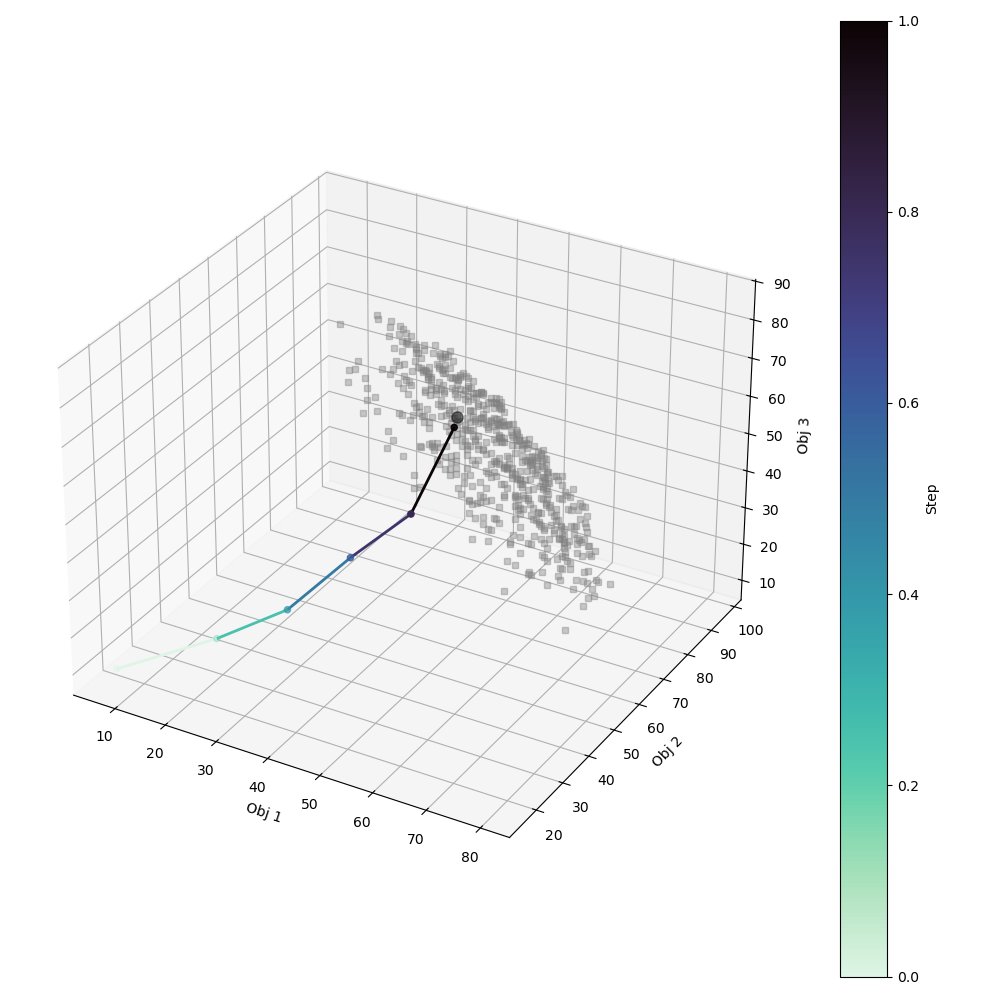

In [101]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
# colors = sns.color_palette("Set2", 6)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub1'

# for trial in range(2, 3):
trial = 6
for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
    print(file)
    data = pd.read_csv(file)

# add and remove  
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')
card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

# find closest pareto front
pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

ax.plot(pf_data[:,0], pf_data[:,1], pf_data[:,2], 's', alpha=0.4, markersize=4, color='grey')
# ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], '-o', alpha=0.9, markersize=4, color=colors)

# plot path
x = obj_data_cumu[:, 0]
y = obj_data_cumu[:, 1]
z = obj_data_cumu[:, 2]
points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
t = np.linspace(0, 1, len(x) - 1)
lc = Line3DCollection(segments, cmap="mako_r", linewidth=1)
lc.set_array(t)
lc.set_linewidth(2)
ax.add_collection(lc)
sc = ax.scatter(x, y, z, c=np.linspace(0,1,len(x)), cmap="mako_r", s=20)
plt.colorbar(sc, ax=ax, label='Step')

ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], '-o', alpha=0.5, markersize=8, color='black', markeredgecolor='black')

ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.tight_layout()
plt.show()

/data/knapsack/card_game_log/pilot_sub4/TrialLog_25a3b5f3-85eb-46b5-99d8-cff0a293c88c_Trial10.csv
[88 80 93 91 85]
[90 86 97 95 87]
8.717797887081348


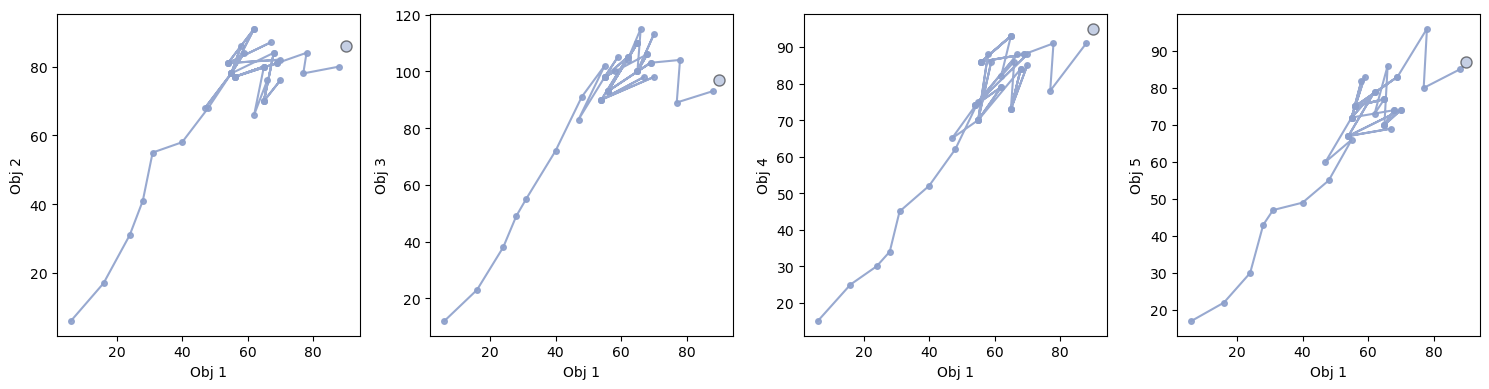

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = sns.color_palette("Set2", 3)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub4'

for trial in range(10, 11):
    for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
        print(file)
        data = pd.read_csv(file)

    # add and remove  
    card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
    mask_add = card_op['operationType'] == 'add'
    mask_remove = card_op['operationType'] == 'remove'
    mask_obj = card_op.columns.str.contains('itemObj')
    card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

    obj_data = card_op.loc[:, mask_obj].values
    obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

    # find closest pareto front
    pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
    dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
    idx = np.argmin(dists)
    closest_pf = pf_data[idx]
    closest_dist = dists[idx]

    print(obj_data_cumu[-1])
    print(closest_pf)
    print(closest_dist)

    for i in range(1, 5):
        # axes[i-1].plot(pf_data[:,0], pf_data[:,i], 's', alpha=0.2, markersize=4, color='grey')
        axes[i-1].plot(obj_data_cumu[:, 0], obj_data_cumu[:, i], '-o', alpha=0.9, markersize=4, color=colors[trial-8])
        axes[i-1].plot(closest_pf[0], closest_pf[i], '-o', alpha=0.5, markersize=8, color=colors[trial-8], markeredgecolor='black')
        axes[i-1].set_xlabel('Obj 1')
        axes[i-1].set_ylabel(f'Obj {i+1}')
plt.tight_layout()
plt.show()